# Gender Bias Detection — Evaluation

**Ground truth:** `services/auto_analysis/output/labeled.yaml`  
**Predictions:** `services/auto_analysis/assets/scraped_data.csv`

Rows are aligned positionally (same order, text verified to match 105 114/105 114).


In [4]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.dpi"] = 130

## 1 Load & Align Data


In [5]:
# ── Load CSV (predictions) ────────────────────────────────────────────────────
csv_path = "services/auto_analysis/assets/scraped_data.csv"
yaml_path = "services/auto_analysis/output/labeled.yaml"

pred_df = pd.read_csv(csv_path)

# ── Load YAML (ground truth) ──────────────────────────────────────────────────
with open(yaml_path) as f:
    raw = yaml.safe_load(f)
gt_df = pd.DataFrame(raw["records"])

assert len(pred_df) == len(gt_df), "Row count mismatch!"
assert (pred_df["text"].astype(str) == gt_df["text"].astype(str)).all(), "Text mismatch!"

# ── Merge into one frame ──────────────────────────────────────────────────────
df = pred_df[["id", "text", "predicted_label", "prediction_score"]].copy()
df["true_label"] = gt_df["label"].values

# ── Normalise label casing / separators ──────────────────────────────────────
PRED_MAP = {
    "neutral": "NEUTRAL",
    "meta_counter": "META_COUNTER",
    "gb-attack": "GB_ATTACK",
    "gb_attack": "GB_ATTACK",
    "gb-normative": "GB_NORMATIVE",
    "gb_normative": "GB_NORMATIVE",
    "gb-sex": "GB_SEX",
    "gb_sex": "GB_SEX",
    "gendered_insult": "GENDERED_INSULT",
    "gendered-insult": "GENDERED_INSULT",
}
df["predicted_label"] = df["predicted_label"].str.lower().map(PRED_MAP).fillna(df["predicted_label"].str.upper())

# Drop NON_GB rows (unresolved catch-all — 532 rows)
df_eval = df[df["true_label"] != "NON_GB"].copy()

CLASS_ORDER = ["GB_ATTACK", "GB_NORMATIVE", "GB_SEX", "GENDERED_INSULT", "META_COUNTER", "NEUTRAL"]

print(f"Total rows: {len(df):,}  |  After dropping NON_GB: {len(df_eval):,}")
df_eval[["true_label", "predicted_label", "prediction_score"]].head()

Total rows: 105,114  |  After dropping NON_GB: 104,582


,true_label,predicted_label,prediction_score
0,NEUTRAL,NEUTRAL,0.888052
1,NEUTRAL,NEUTRAL,0.882806
2,NEUTRAL,NEUTRAL,0.883822
3,NEUTRAL,NEUTRAL,0.876902
4,NEUTRAL,NEUTRAL,0.887742


## 2 Class Distribution — Ground Truth vs Predicted


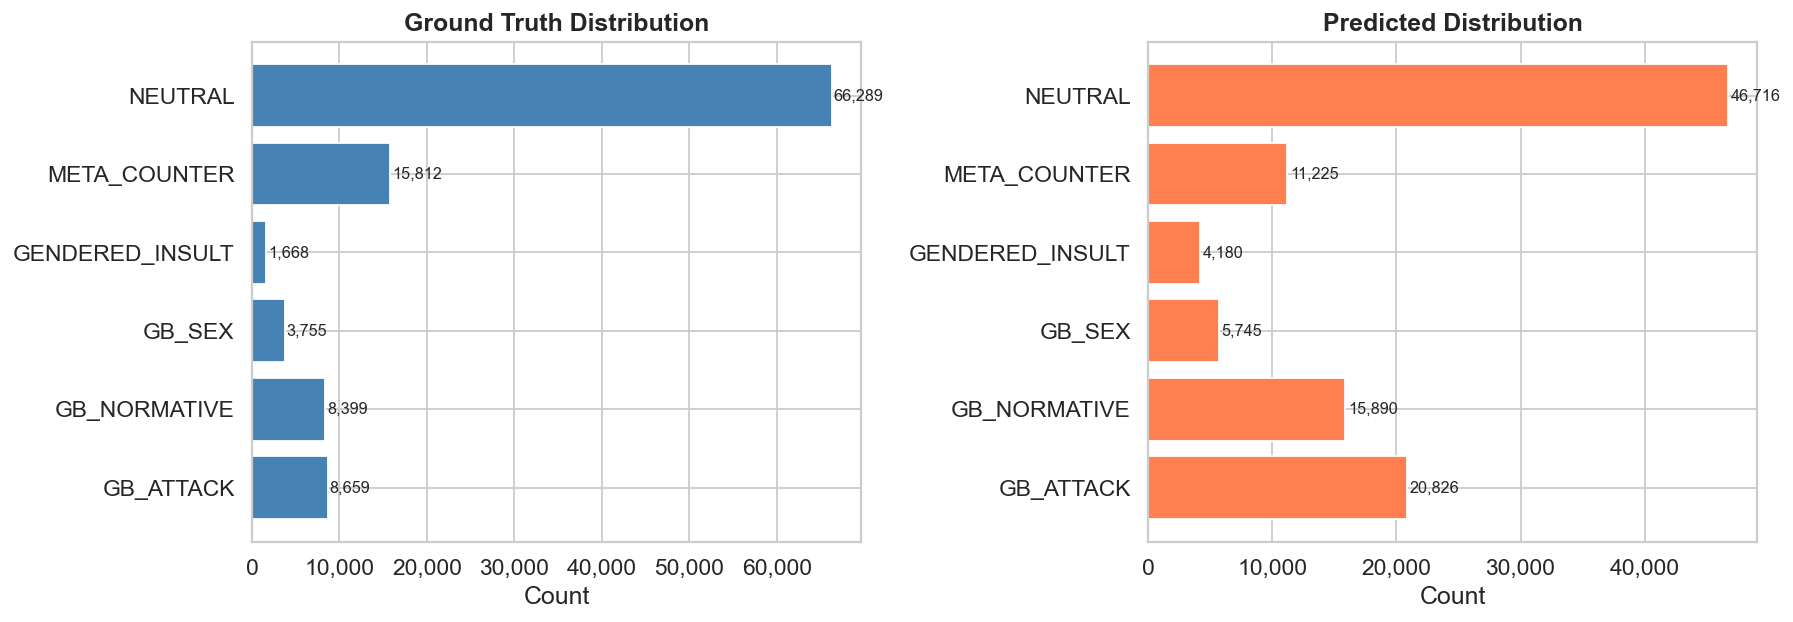

,true,predicted,delta,true_%,pred_%
GB_ATTACK,8659,20826,12167,8.3,19.9
GB_NORMATIVE,8399,15890,7491,8.0,15.2
GB_SEX,3755,5745,1990,3.6,5.5
GENDERED_INSULT,1668,4180,2512,1.6,4.0
META_COUNTER,15812,11225,-4587,15.1,10.7
NEUTRAL,66289,46716,-19573,63.4,44.7


In [6]:
true_counts = df_eval["true_label"].value_counts().reindex(CLASS_ORDER)
pred_counts = df_eval["predicted_label"].value_counts().reindex(CLASS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title, color in zip(
    axes,
    [true_counts, pred_counts],
    ["Ground Truth Distribution", "Predicted Distribution"],
    ["steelblue", "coral"],
):
    bars = ax.barh(counts.index, counts.values, color=color, edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Count")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, val in zip(bars, counts.values):
        ax.text(val + 200, bar.get_y() + bar.get_height() / 2, f"{val:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# Side-by-side table
dist_df = pd.DataFrame({"true": true_counts, "predicted": pred_counts})
dist_df["delta"] = dist_df["predicted"] - dist_df["true"]
dist_df["true_%"] = (dist_df["true"] / dist_df["true"].sum() * 100).round(1)
dist_df["pred_%"] = (dist_df["predicted"] / dist_df["predicted"].sum() * 100).round(1)
dist_df

## 3 Overall Metrics


In [7]:
y_true = df_eval["true_label"]
y_pred = df_eval["predicted_label"]

acc = accuracy_score(y_true, y_pred)
mac_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
wei_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
mac_prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
mac_rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

summary = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Macro F1", "Weighted F1", "Macro Precision", "Macro Recall"],
        "Score": [acc, mac_f1, wei_f1, mac_prec, mac_rec],
    }
)
summary["Score"] = summary["Score"].round(4)
summary.set_index("Metric")

,Score
Metric,
Accuracy,0.6810
Macro F1,0.5851
Weighted F1,0.7147
Macro Precision,0.5569
Macro Recall,0.7197


## 4 Per-Class Report


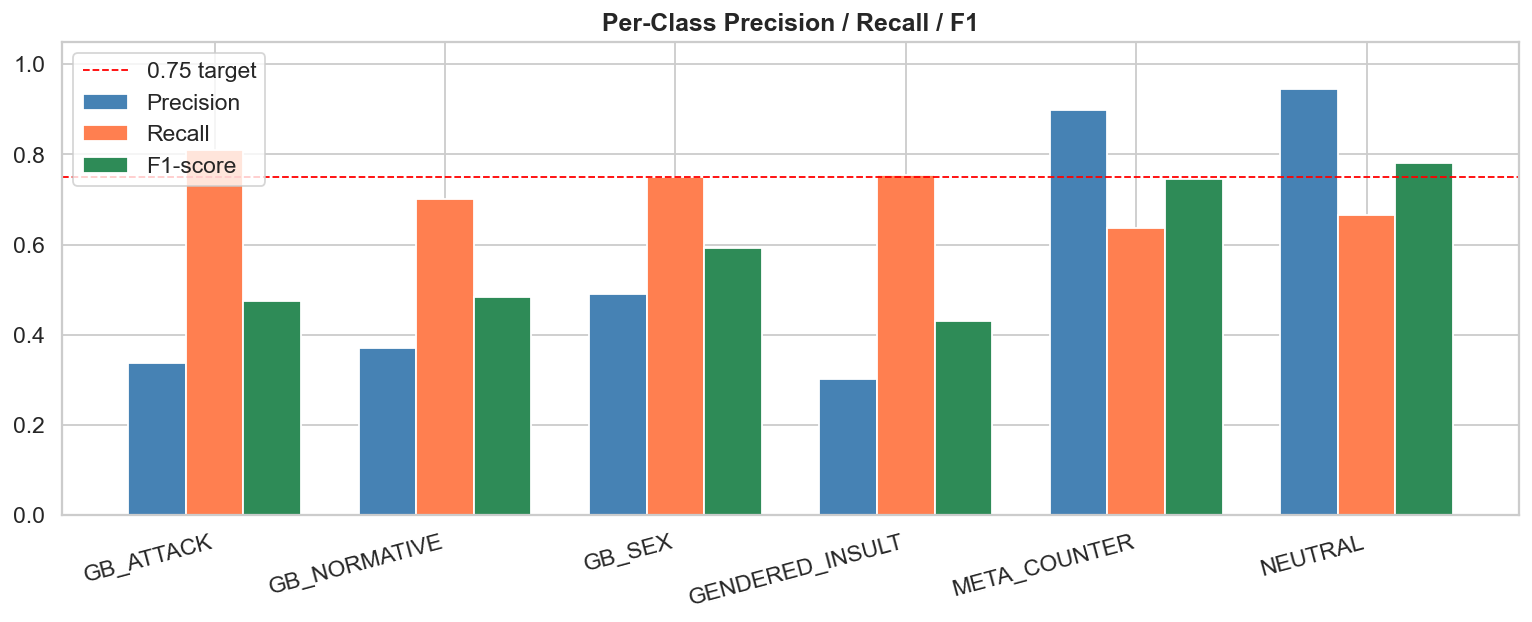

,precision,recall,f1-score,support
GB_ATTACK,0.3364,0.8090,0.4752,8659.0
GB_NORMATIVE,0.3702,0.7004,0.4844,8399.0
GB_SEX,0.4902,0.7499,0.5928,3755.0
GENDERED_INSULT,0.3012,0.7548,0.4306,1668.0
META_COUNTER,0.8981,0.6376,0.7457,15812.0
NEUTRAL,0.9456,0.6664,0.7818,66289.0


In [8]:
report = classification_report(
    y_true,
    y_pred,
    labels=CLASS_ORDER,
    output_dict=True,
    zero_division=0,
)
per_class = pd.DataFrame(report).T.loc[CLASS_ORDER]
per_class[["precision", "recall", "f1-score", "support"]] = per_class[
    ["precision", "recall", "f1-score", "support"]
].apply(pd.to_numeric)

# Bar chart — precision / recall / F1 per class
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(CLASS_ORDER))
w = 0.25
ax.bar(x - w, per_class["precision"], w, label="Precision", color="steelblue")
ax.bar(x, per_class["recall"], w, label="Recall", color="coral")
ax.bar(x + w, per_class["f1-score"], w, label="F1-score", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_ORDER, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.axhline(0.75, color="red", linestyle="--", linewidth=1, label="0.75 target")
ax.set_title("Per-Class Precision / Recall / F1", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

per_class[["precision", "recall", "f1-score", "support"]].round(4)

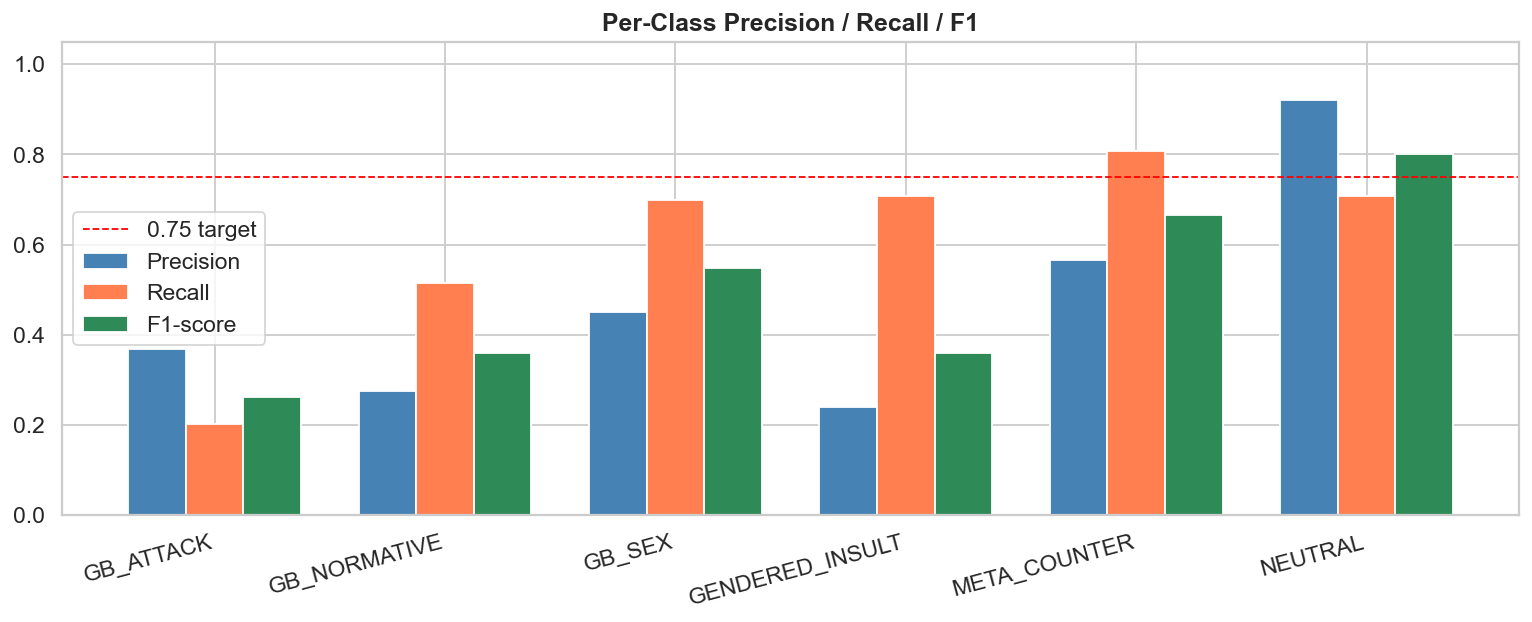

,precision,recall,f1-score,support
GB_ATTACK,0.3679,0.2021,0.2609,8659.0
GB_NORMATIVE,0.2752,0.5141,0.3585,8399.0
GB_SEX,0.4513,0.6980,0.5482,3755.0
GENDERED_INSULT,0.2405,0.7086,0.3592,1668.0
META_COUNTER,0.5669,0.8065,0.6658,15812.0
NEUTRAL,0.9213,0.7077,0.8005,66289.0


In [ ]:
report = classification_report(
    y_true,
    y_pred,
    labels=CLASS_ORDER,
    output_dict=True,
    zero_division=0,
)
per_class = pd.DataFrame(report).T.loc[CLASS_ORDER]
per_class[["precision", "recall", "f1-score", "support"]] = per_class[
    ["precision", "recall", "f1-score", "support"]
].apply(pd.to_numeric)

# Bar chart — precision / recall / F1 per class
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(CLASS_ORDER))
w = 0.25
ax.bar(x - w, per_class["precision"], w, label="Precision", color="steelblue")
ax.bar(x, per_class["recall"], w, label="Recall", color="coral")
ax.bar(x + w, per_class["f1-score"], w, label="F1-score", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_ORDER, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.axhline(0.75, color="red", linestyle="--", linewidth=1, label="0.75 target")
ax.set_title("Per-Class Precision / Recall / F1", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

per_class[["precision", "recall", "f1-score", "support"]].round(4)

## 5 Confusion Matrix


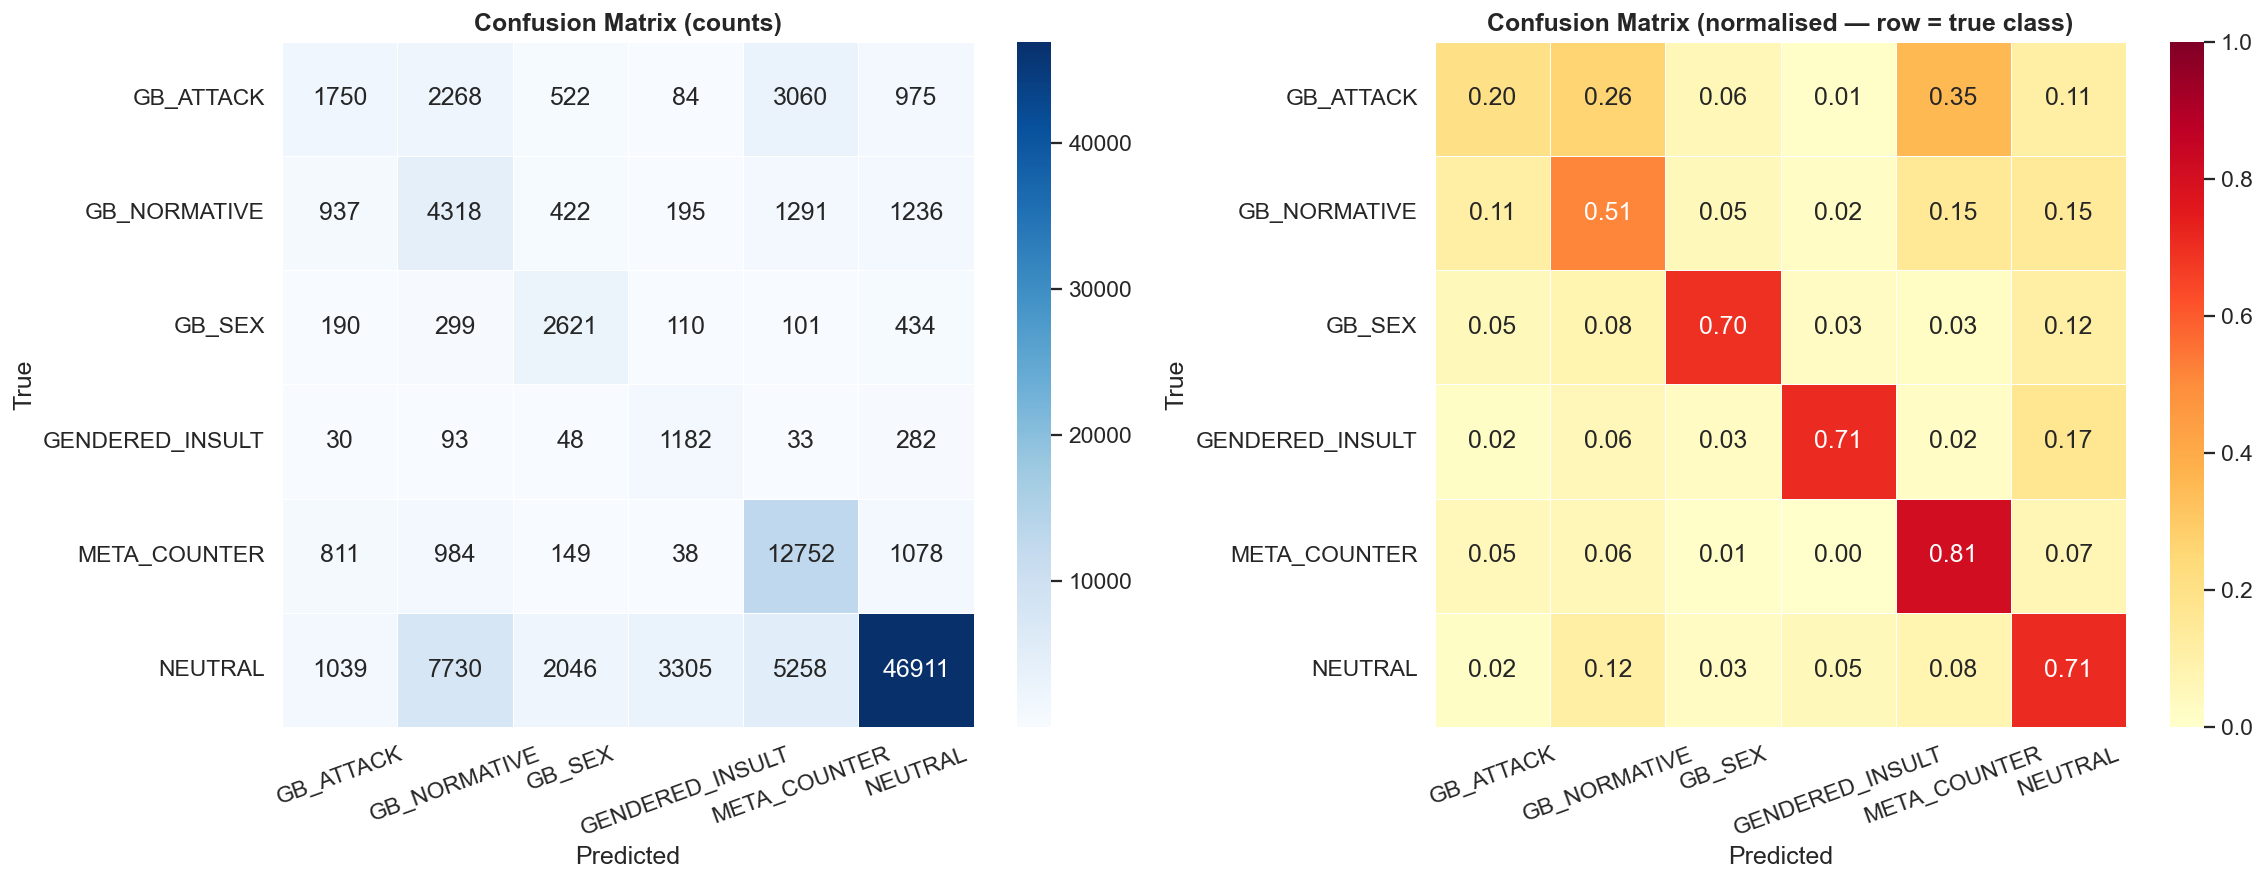

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix (counts)", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=20)

# Normalised (recall per row)
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    linewidths=0.5,
    vmin=0,
    vmax=1,
    ax=axes[1],
)
axes[1].set_title("Confusion Matrix (normalised — row = true class)", fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 6 Top Confusion Pairs


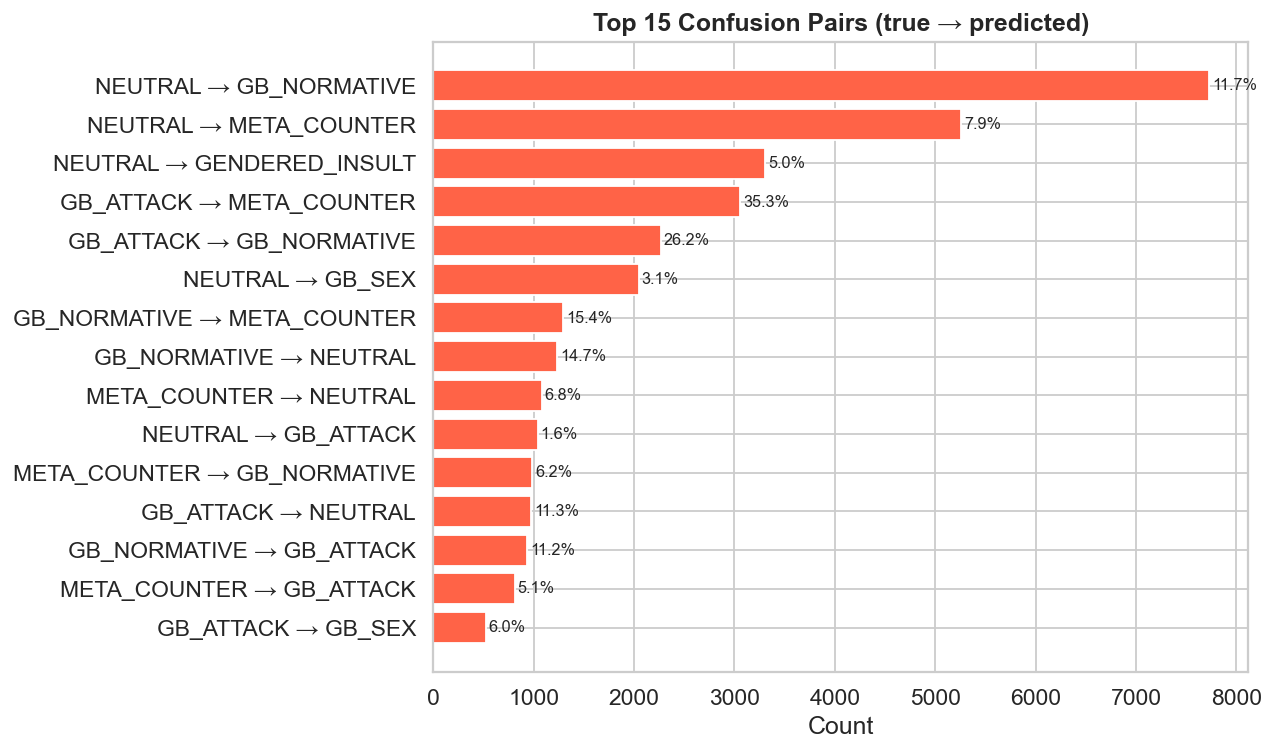

,pair,count,rate
0,NEUTRAL → GB_NORMATIVE,7730,0.116611
1,NEUTRAL → META_COUNTER,5258,0.079319
2,NEUTRAL → GENDERED_INSULT,3305,0.049857
3,GB_ATTACK → META_COUNTER,3060,0.353390
4,GB_ATTACK → GB_NORMATIVE,2268,0.261924
5,NEUTRAL → GB_SEX,2046,0.030865
6,GB_NORMATIVE → META_COUNTER,1291,0.153709
7,GB_NORMATIVE → NEUTRAL,1236,0.147160
8,META_COUNTER → NEUTRAL,1078,0.068176
9,NEUTRAL → GB_ATTACK,1039,0.015674


In [ ]:
pairs = []
for i, true_cls in enumerate(CLASS_ORDER):
    for j, pred_cls in enumerate(CLASS_ORDER):
        if i != j:
            pairs.append(
                {
                    "true": true_cls,
                    "predicted": pred_cls,
                    "count": cm[i, j],
                    "rate": cm_norm[i, j],
                }
            )

pairs_df = pd.DataFrame(pairs).sort_values("count", ascending=False).head(15).reset_index(drop=True)
pairs_df["pair"] = pairs_df["true"] + " → " + pairs_df["predicted"]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(pairs_df["pair"][::-1], pairs_df["count"][::-1], color="tomato", edgecolor="white")
for bar, rate in zip(bars, pairs_df["rate"][::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2, f"{rate:.1%}", va="center", fontsize=9)
ax.set_title("Top 15 Confusion Pairs (true → predicted)", fontweight="bold")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

pairs_df[["pair", "count", "rate"]].head(15)

## 7 Prediction Score Distribution


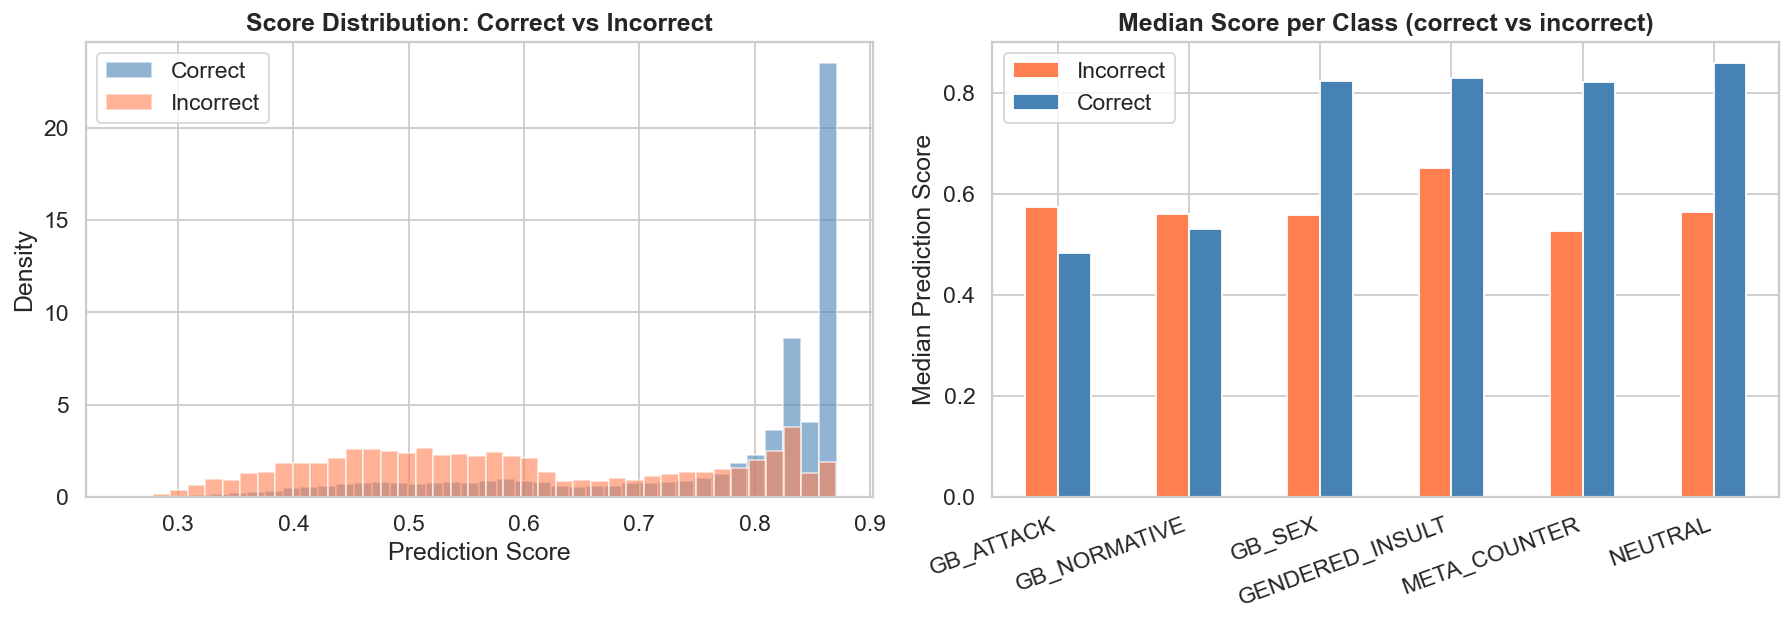

In [ ]:
df_eval["correct"] = df_eval["true_label"] == df_eval["predicted_label"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution split by correct / incorrect
for is_correct, label, color in [(True, "Correct", "steelblue"), (False, "Incorrect", "coral")]:
    axes[0].hist(
        df_eval.loc[df_eval["correct"] == is_correct, "prediction_score"],
        bins=40,
        alpha=0.6,
        label=label,
        color=color,
        density=True,
    )
axes[0].set_title("Score Distribution: Correct vs Incorrect", fontweight="bold")
axes[0].set_xlabel("Prediction Score")
axes[0].set_ylabel("Density")
axes[0].legend()

# Median score per true class, split by correct/incorrect
score_by_class = df_eval.groupby(["true_label", "correct"])["prediction_score"].median().unstack()
score_by_class = score_by_class.reindex(CLASS_ORDER)
score_by_class.plot(kind="bar", ax=axes[1], color=["coral", "steelblue"], edgecolor="white")
axes[1].set_title("Median Score per Class (correct vs incorrect)", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Median Prediction Score")
axes[1].set_xticklabels(CLASS_ORDER, rotation=20, ha="right")
axes[1].legend(["Incorrect", "Correct"])

plt.tight_layout()
plt.show()

## 8 Score vs Accuracy — Confidence Calibration


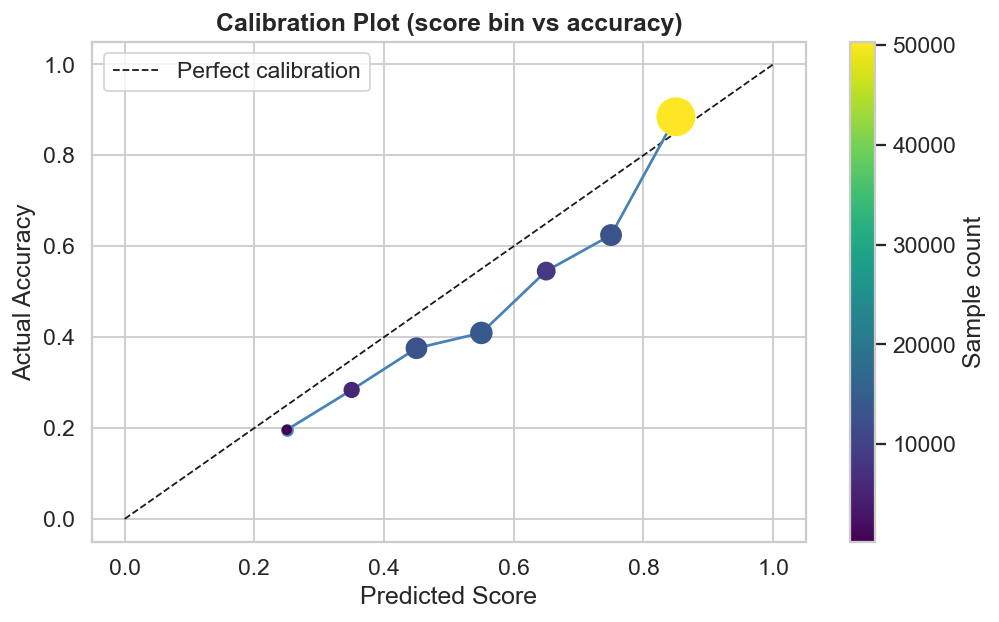

In [ ]:
bins = np.linspace(0, 1, 11)
df_eval["score_bin"] = pd.cut(df_eval["prediction_score"], bins=bins)
calib = (
    df_eval.groupby("score_bin", observed=True)
    .agg(
        accuracy=("correct", "mean"),
        count=("correct", "count"),
    )
    .reset_index()
)
calib["bin_mid"] = calib["score_bin"].apply(lambda x: x.mid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
sc = ax.scatter(
    calib["bin_mid"],
    calib["accuracy"],
    s=calib["count"] / calib["count"].max() * 400 + 20,
    c=calib["count"],
    cmap="viridis",
    zorder=3,
)
ax.plot(calib["bin_mid"], calib["accuracy"], "o-", color="steelblue", zorder=2)
plt.colorbar(sc, label="Sample count")
ax.set_title("Calibration Plot (score bin vs accuracy)", fontweight="bold")
ax.set_xlabel("Predicted Score")
ax.set_ylabel("Actual Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

## 9 Error Rate per Class


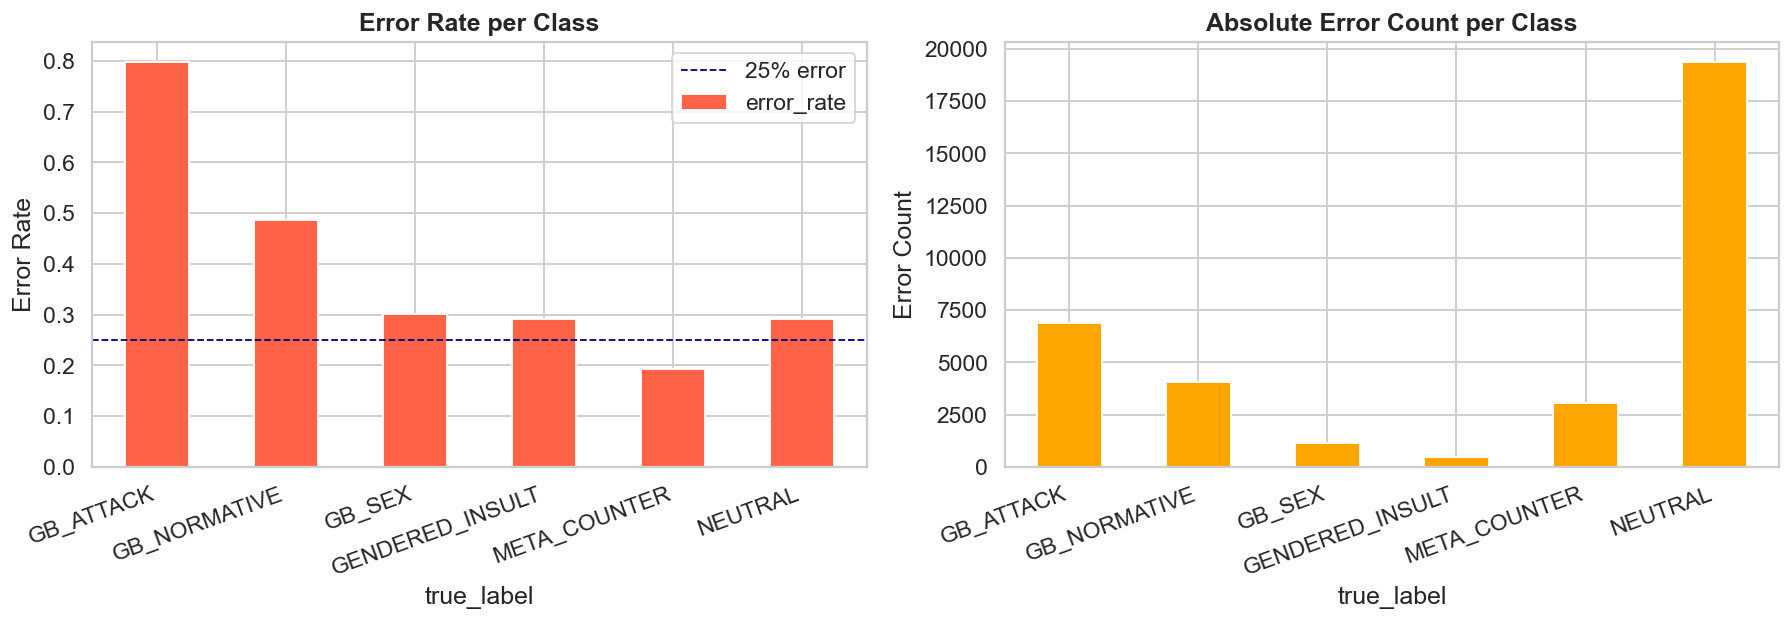

,total,correct,error_count,error_rate
true_label,,,,
GB_ATTACK,8659,1750,6909,0.7979
GB_NORMATIVE,8399,4318,4081,0.4859
GB_SEX,3755,2621,1134,0.3020
GENDERED_INSULT,1668,1182,486,0.2914
META_COUNTER,15812,12752,3060,0.1935
NEUTRAL,66289,46911,19378,0.2923


In [ ]:
error_rate = (
    df_eval.groupby("true_label")["correct"]
    .agg(
        total="count",
        correct="sum",
    )
    .assign(
        error_rate=lambda x: 1 - x["correct"] / x["total"],
        error_count=lambda x: x["total"] - x["correct"],
    )
    .reindex(CLASS_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

error_rate["error_rate"].plot(kind="bar", ax=axes[0], color="tomato", edgecolor="white")
axes[0].set_title("Error Rate per Class", fontweight="bold")
axes[0].set_ylabel("Error Rate")
axes[0].set_xticklabels(CLASS_ORDER, rotation=20, ha="right")
axes[0].axhline(0.25, color="navy", linestyle="--", linewidth=1, label="25% error")
axes[0].legend()

error_rate["error_count"].plot(kind="bar", ax=axes[1], color="orange", edgecolor="white")
axes[1].set_title("Absolute Error Count per Class", fontweight="bold")
axes[1].set_ylabel("Error Count")
axes[1].set_xticklabels(CLASS_ORDER, rotation=20, ha="right")

plt.tight_layout()
plt.show()

error_rate[["total", "correct", "error_count", "error_rate"]].round(4)

## 10 Bleed Analysis — Where Does Each Class Leak?


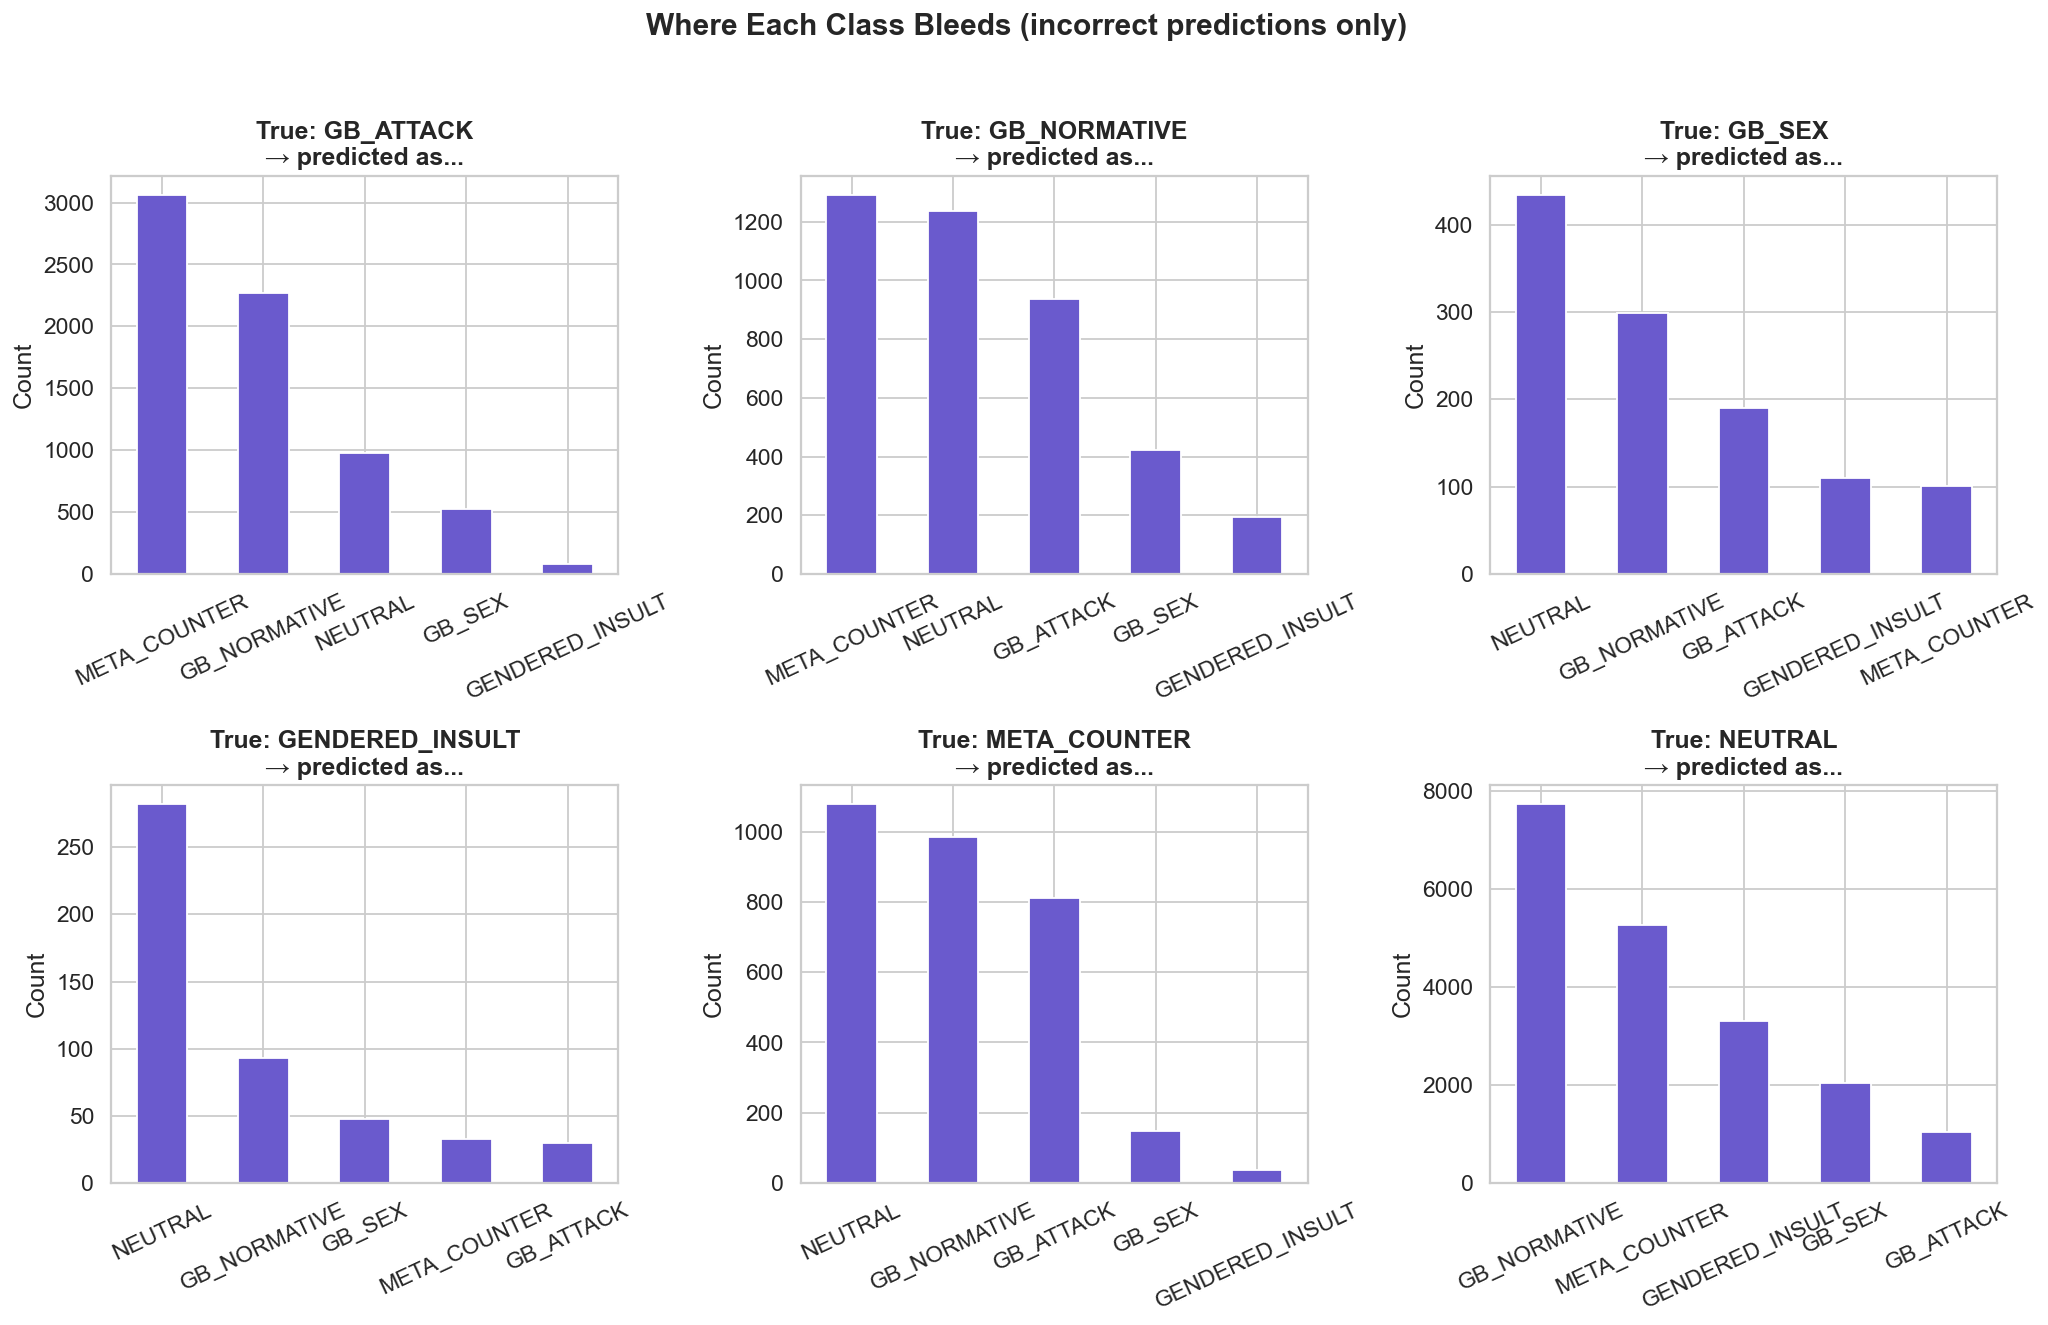

In [ ]:
wrong = df_eval[~df_eval["correct"]]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, cls in zip(axes.flat, CLASS_ORDER):
    subset = wrong[wrong["true_label"] == cls]["predicted_label"].value_counts()
    if subset.empty:
        ax.set_visible(False)
        continue
    subset.plot(kind="bar", ax=ax, color="slateblue", edgecolor="white")
    ax.set_title(f"True: {cls}\n→ predicted as...", fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Where Each Class Bleeds (incorrect predictions only)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 11 Sample Errors per Class


In [ ]:
N_SAMPLES = 5

for cls in CLASS_ORDER:
    subset = wrong[wrong["true_label"] == cls].copy()
    if subset.empty:
        continue
    sample = subset.sample(min(N_SAMPLES, len(subset)), random_state=42)
    sep = "=" * 70
    print(f"\n{sep}")
    print(f"True class: {cls}  ({len(subset):,} errors)")
    print(sep)
    for _, row in sample.iterrows():
        print(f"  Predicted : {row['predicted_label']}  (score={row['prediction_score']:.3f})")
        print(f"  Text      : {row['text'][:120]}")
        print()


True class: GB_ATTACK  (6,909 errors)
  Predicted : META_COUNTER  (score=0.793)
  Text      : ชาวทวิตนิสัยเป็นแบบนี้กันหมดเลยไหมคะ เหยียดคนด่าคนเป็นเรื่องปกติแย่มาก

  Predicted : GB_NORMATIVE  (score=0.479)
  Text      : คนเขามีธุระเหมือนกัน อาจจะพึ่งได้กลับบ้านค่ะอิดอกใครมันจะเหมือนมึงหล่ะอิหน้าสนตีน คนอย่างมึงต้องโดนปล้นจี้แล้วปาดคอตายห่

  Predicted : META_COUNTER  (score=0.376)
  Text      : มุกยอดนิยมเฟมทวิตเลยครับสูตรสำเร็จเหมือนกันทุกดราม่า ไล่คนอื่นไปอ่านไปหาข้อมูล

  Predicted : META_COUNTER  (score=0.640)
  Text      : เอาไปด่าแขวนก็เรื่องปกตินี่ครับ ไม่ใช่ก็แค่ออกมาชี้แจ้งแค่นั้น ทำเป็นเรื่องใหญ่ไปได้

  Predicted : META_COUNTER  (score=0.505)
  Text      : เชื่อว่าคนที่ได้ดู mv นี้ต้องมีคำถาม คำถามเดียวกัน คือ... ตอนเด็ก นางเอกดัดฟันแล้วไม่ใช้หรอ หัวเราะ


True class: GB_NORMATIVE  (4,081 errors)
  Predicted : GB_ATTACK  (score=0.610)
  Text      : งั้นอีพวกผู้ชายทั้งหลายก็ควรอยู่บ้านจ้าไม่ใช่ออกไปเป็นภาระให้ผู้หญิงคนอื่นเค้ากลัวกัน อีดอก

  Predicted : GB_ATTACK  (score=

## 12 Summary Dashboard


In [ ]:
print("╔══════════════════════════════════════════════════════╗")
print("║            EVALUATION SUMMARY                       ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Total samples      : {len(df_eval):>8,}                    ║")
print(f"║  Accuracy           : {acc:>8.4f}                    ║")
print(f"║  Macro F1           : {mac_f1:>8.4f}                    ║")
print(f"║  Weighted F1        : {wei_f1:>8.4f}                    ║")
print(f"║  Macro Precision    : {mac_prec:>8.4f}                    ║")
print(f"║  Macro Recall       : {mac_rec:>8.4f}                    ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  Per-class F1 scores                                 ║")
for cls in CLASS_ORDER:
    f1 = report[cls]["f1-score"]
    bar = "█" * int(f1 * 20)
    flag = "⚠" if f1 < 0.75 else " "
    print(f"║  {cls:<18s} {f1:.3f}  {flag} {bar:<20s}  ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║            EVALUATION SUMMARY                       ║
╠══════════════════════════════════════════════════════╣
║  Total samples      :  104,582                    ║
║  Accuracy           :   0.6649                    ║
║  Macro F1           :   0.4988                    ║
║  Weighted F1        :   0.6839                    ║
║  Macro Precision    :   0.4705                    ║
║  Macro Recall       :   0.6062                    ║
╠══════════════════════════════════════════════════════╣
║  Per-class F1 scores                                 ║
║  GB_ATTACK          0.261  ⚠ █████                 ║
║  GB_NORMATIVE       0.358  ⚠ ███████               ║
║  GB_SEX             0.548  ⚠ ██████████            ║
║  GENDERED_INSULT    0.359  ⚠ ███████               ║
║  META_COUNTER       0.666  ⚠ █████████████         ║
║  NEUTRAL            0.800    ████████████████      ║
╚══════════════════════════════════════════════════════╝
